# LSTM-SVR-L model

In [17]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import os


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [19]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [20]:
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
df.head()
df.tail()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,p_sigma,p_r,p_d,regime,regime_id,log_realized_variance,rv_lag1,rv_lag2,rv_lag3,rv_rolling_mean_30
3120,2026-01-27,0.009776,0.000485,0.022018,-0.061538,-0.104979,-0.046198,0.021370,-0.235868,8.775873,...,0.866667,0.700000,0.583333,High,1.0,-7.631798,-7.940211,-8.366620,-10.489060,-8.413804
3121,2026-01-28,0.000510,0.000319,0.017847,-0.065574,-0.075153,0.240570,0.021306,0.359595,8.800436,...,0.533333,0.533333,0.500000,High,1.0,-8.051862,-7.631798,-7.940211,-8.366620,-8.431558
3122,2026-01-29,-0.053552,0.001190,0.034490,0.333333,0.243422,-0.024924,0.071430,0.118684,9.606559,...,0.966667,0.033333,0.966667,High,1.0,-6.734192,-8.051862,-7.631798,-7.940211,-8.370003
3123,2026-01-30,-0.004770,0.000855,0.029246,0.171053,-0.118552,0.068726,0.107636,0.416170,9.631273,...,0.933333,0.300000,0.816667,High,1.0,-7.064056,-6.734192,-8.051862,-7.631798,-8.314689
3124,2026-01-31,-0.067155,0.000998,0.031598,0.123596,0.062615,-0.051867,-0.096210,-0.546907,9.606164,...,0.933333,0.033333,0.950000,High,1.0,-6.909322,-7.064056,-6.734192,-8.051862,-8.224822


In [21]:
lstm_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
    ]

svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

## Weighted LSTM Objective

Each observation is assigned a weight

$$
w_t = (1-\lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}}
+
\lambda
\frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}
{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}\mathbf{1}\{g_s \ne g_{s-1}\}}
$$

where

- $T$ is the number of observations  
- $g_t$ is the regime label at time $t$  
- $\mathbf{1}\{\cdot\}$ is the indicator function  
- $\lambda \in [0,1]$ controls the emphasis on regime switching observations.

The LSTM is trained using a **weighted categorical cross-entropy loss**

$$
\mathcal{L} =
-\frac{1}{T}
\sum_{t=1}^{T}
w_t
\sum_{k=1}^{K}
y_{t,k}\log(\hat{y}_{t,k})
$$

where

- $K$ = number of regimes  
- $y_{t,k}$ = true indicator of regime $k$ at time $t$  
- $\hat{y}_{t,k}$ = predicted probability from the LSTM softmax layer  
- $w_t$ = observation weight.

In [22]:
def compute_weights(regimes, lam=0.5, eps=1e-12):
    regimes = np.asarray(regimes).astype(int)
    T = len(regimes)

    switch_flag = np.zeros(T, dtype=int)
    switch_flag[1:] = (regimes[1:] != regimes[:-1]).astype(int)

    unique_regimes = np.unique(regimes)

    class_count = {g: np.sum(regimes == g) for g in unique_regimes}
    switch_count = {
        g: np.sum((regimes == g) & (switch_flag == 1))
        for g in unique_regimes
    }
    total_switches = np.sum(switch_flag)

    weights = np.zeros(T, dtype=float)

    for t in range(T):
        g = regimes[t]

        imbalance_term = T / (class_count[g] + eps)

        if total_switches > 0 and switch_count[g] > 0:
            switch_term = total_switches / (switch_count[g] + eps)
        else:
            switch_term = 0.0 

        weights[t] = (1 - lam) * imbalance_term + lam * switch_term 

    # normalize weights for stability
    weights = weights / np.mean(weights)

    return weights, switch_flag

In [23]:
# use this for evaluation and testing
def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback - 1, scale_window - 1)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

In [24]:
def create_rolling_scaled_sequences_range_weights(
    df, feature_cols, target_col, lookback, scale_window,
    start_idx, end_idx, weights_full, date_col=None
):
    X, y, dates, target_idx, w = [], [], [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]
        target = df[target_col].iloc[t + 1]

        weight = weights_full[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        if pd.isna(weight):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)
        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)
        w.append(weight)
        target_idx.append(t + 1)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates, np.array(w), np.array(target_idx)


def scale_rolling(df_hist, feature_cols, lookback, scale_window=730):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler


In [25]:
def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [26]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

# SVR-Linear

In [27]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000, random_state = SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [28]:
def rolling_lstm_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]

    prob_cols = ["prob1_for_next_day"] if use_prob_1_only else ["prob0_for_next_day", "prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training ends at t-1, so row t is excluded
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "var_svr": np.nan
            })
            continue

        # split continuous features and probability features
        X_train_cont = train_df[x_feature_cols].values
        X_train_prob = train_df[prob_cols].values
        y_train = train_df["rv_lead1"].values

        # scale only continuous features
        scaler = StandardScaler()
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)

        # combine scaled continuous features with raw probabilities
        X_train_final = np.hstack([X_train_cont_scaled, X_train_prob])

        model = fit_svr_safe(
            X_train=X_train_final,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        # prepare current row features for forecasting t+1
        x_t_cont = current_row[x_feature_cols]
        x_t_prob = current_row[prob_cols]

        if x_t_cont.isna().any() or x_t_prob.isna().any():
            pred = np.nan
        else:
            x_t_cont_scaled = scaler.transform(x_t_cont.values.reshape(1, -1))
            x_t_prob_arr = x_t_prob.values.reshape(1, -1)
            x_t_final = np.hstack([x_t_cont_scaled, x_t_prob_arr])

            pred = one_step_svr_forecast(model, x_t_final)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_log_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "log_var_svr": pred
        })

    return pd.DataFrame(results)

#### metrics

In [29]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


In [30]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
import tensorflow as tf
import gc
from itertools import product 
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler


In [31]:
n = len(df)

train_size = int(n * 0.60)  # 60/25/15 split
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

# split eval into A and B
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

train_df = df.iloc[train_start_idx:train_end_idx].copy()
evalA_df = df.iloc[evalA_start_idx:evalA_end_idx].copy()
evalB_df = df.iloc[evalB_start_idx:evalB_end_idx].copy()
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set:  {len(train_df)} rows")
print(f"Eval A set: {len(evalA_df)} rows")
print(f"Eval B set: {len(evalB_df)} rows")
print(f"Test set:   {len(test_df)} rows")

Train set:  1875 rows
Eval A set: 390 rows
Eval B set: 391 rows
Test set:   469 rows


In [32]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [33]:
lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.1, 0.2],
    "batch_size": [32,64]
}

lstm_param_grid = []
for lb, units, drop, bs in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"]
):
    lstm_param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs
    })


svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })

print(f"Total LSTM configs: {len(lstm_param_grid)}")
print(f"Total SVR configs: {len(svr_param_grid)}")

Total LSTM configs: 36
Total SVR configs: 9


#### Tune LSTM on fixed SVR

In [17]:
fixed_svr_params = {
    "kernel": "linear",
    "C": 1.0,
    "epsilon": 1e-4
}

stage2_window = 365
min_obs = 200

lstm_results = []

for i, params in enumerate(lstm_param_grid, 1):
    lb = params["lookback"]
    units = params["units"]
    drop = params["dropout"]
    bs = params["batch_size"]

    print(f"\n[{i}/{len(lstm_param_grid)}] Testing LSTM: {params}")

    try:
        K.clear_session()
        tf.keras.backend.clear_session()
        gc.collect()

        # -----------------------------
        # 1) Train LSTM on TRAIN only
        # -----------------------------
        train_weights_full, train_switch_flags = compute_weights(
            train_df["regime_id"].values, lam=0.5
        )

        X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
            create_rolling_scaled_sequences_range_weights(
                df=train_df,
                feature_cols=lstm_features,
                target_col="regime_id",
                lookback=lb,
                scale_window=365,
                start_idx=0,
                end_idx=len(train_df),
                weights_full=train_weights_full,
                date_col="date"
            )
        )

        w_train = w_train.astype(np.float32)

        # -----------------------------------
        # 2) Validate LSTM on Eval A only
        # -----------------------------------
        X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
            df=df,
            feature_cols=lstm_features,
            target_col="regime_id",
            lookback=lb,
            scale_window=365,
            start_idx=evalA_start_idx,
            end_idx=evalA_end_idx,
            date_col="date"
        )

        if len(X_train_lstm) == 0 or len(X_evalA_lstm) == 0:
            print("Skipping: no sequences produced.")
            lstm_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no sequences produced"
            })
            continue

        y_train_cat = to_categorical(y_train_regime, num_classes=2)
        y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

        model = build_lstm_model(
            lookback=lb,
            n_features=len(lstm_features),
            n_regimes=2,
            units=units,
            dropout=drop,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train_lstm,
            y_train_cat,
            sample_weight=w_train,
            validation_data=(X_evalA_lstm, y_evalA_cat),
            epochs=100,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )

        # ---------------------------------------------------------
        # 3) Generate regime probabilities on Eval A + Eval B
        #    starting early enough for stage-2 rolling history
        # ---------------------------------------------------------
        regime_start_idx = max(0, evalA_start_idx - stage2_window)

        evalAB_regime_roll = rolling_regime_forecast(
            df_full=df,
            lstm_model=model,
            feature_cols=lstm_features,
            lookback=lb,
            start_idx=regime_start_idx,
            end_idx=evalB_end_idx,
            scale_window=365,
            date_col="date",
            target_col="regime_id"
        )

        # ------------------------------------------------
        # 4) Tune/evaluate stage-2 SVR on Eval B only
        # ------------------------------------------------
        evalB_stage2 = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalAB_regime_roll,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=stage2_window,
            C=fixed_svr_params["C"],
            epsilon=fixed_svr_params["epsilon"],
            min_obs=min_obs,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_stage2["actual_log_var"], evalB_stage2["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_stage2["actual_log_var"]), np.exp(evalB_stage2["log_var_svr"]))
        n_evalB_forecasts = evalB_stage2["log_var_svr"].notna().sum()

        lstm_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        print(f"Error for params {params}: {e}")
        lstm_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

lstm_results_df = pd.DataFrame(lstm_results).sort_values("evalB_qlike")
print(lstm_results_df.head())


[1/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32}


2026-03-25 17:32:32.111314: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz



[2/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 64}

[3/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 32}

[4/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 64}

[5/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 32}

[6/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 64}

[7/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 32}

[8/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 64}

[9/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 32}

[10/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 64}

[11/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'batch_size': 32}

[12/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'batch_size': 64}

[13/36] Testing LSTM: {'lookback': 30, 'units': 32

In [18]:
lstm_results

[{'lookback': 20,
  'units': 32,
  'dropout': 0.0,
  'batch_size': 32,
  'evalB_rmse': 0.9819063770637787,
  'evalB_qlike': 0.5712770710516177,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.0,
  'batch_size': 64,
  'evalB_rmse': 0.9822372762592704,
  'evalB_qlike': 0.5653514187748675,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.1,
  'batch_size': 32,
  'evalB_rmse': 0.9714292462025305,
  'evalB_qlike': 0.5607444942548102,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.1,
  'batch_size': 64,
  'evalB_rmse': 0.989443807780451,
  'evalB_qlike': 0.5791294021473683,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.2,
  'batch_size': 32,
  'evalB_rmse': 0.9831388572095238,
  'evalB_qlike': 0.5536734770456331,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.2,
  'batch_size': 64,
  'evalB_rmse': 0.9818934869936723,
  'evalB_qlike': 0.5820792315

#### Tune svr on best LSTM parameters

In [19]:
lstm_results_df.head()

,lookback,units,dropout,batch_size,evalB_rmse,evalB_qlike,n_evalB_forecasts
25,60,32,0.0,64,0.976895,0.536974,391
18,30,64,0.0,32,0.961662,0.539798,391
7,20,64,0.0,64,0.973208,0.553134,391
4,20,32,0.2,32,0.983139,0.553673,391
24,60,32,0.0,32,0.976444,0.554362,391


In [20]:
best_lstm_params = lstm_results_df.iloc[0].to_dict()
print(best_lstm_params)

{'lookback': 60.0, 'units': 32.0, 'dropout': 0.0, 'batch_size': 64.0, 'evalB_rmse': 0.9768947768310244, 'evalB_qlike': 0.5369744876826811, 'n_evalB_forecasts': 391.0}


In [21]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])

train_weights_full, train_switch_flags = compute_weights(
    train_df["regime_id"].values, lam=0.5
)

# 1) Train LSTM on TRAIN only
X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_df),
        weights_full=train_weights_full,
        date_col="date"
    )
)

w_train = w_train.astype(np.float32)
y_train_cat = to_categorical(y_train_regime, num_classes=2)

# 2) Validate / early stop on EVAL A only
X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
    df=df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=365,
    start_idx=evalA_start_idx,
    end_idx=evalA_end_idx,
    date_col="date"
)

y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

best_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_lstm_model.fit(
    X_train_lstm,
    y_train_cat,
    sample_weight=w_train,
    validation_data=(X_evalA_lstm, y_evalA_cat),
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop],
    verbose=0
)

# 3) Generate fixed regime probabilities for SVR tuning on Eval B
# start early enough so stage-2 has rolling history
stage2_window = 365
regime_start_idx = max(0, evalB_start_idx - stage2_window)

eval_regime_fixed = rolling_regime_forecast(
    df_full=df,
    lstm_model=best_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

In [22]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        evalB_svr = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_stage2["actual_log_var"], evalB_stage2["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_stage2["actual_log_var"]), np.exp(evalB_stage2["log_var_svr"]))
        n_evalB_forecasts = evalB_stage2["log_var_svr"].notna().sum()

        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}
   kernel    C  epsilon  evalB_rmse  evalB_qlike  n_evalB_forecasts
0  linear  0.1   0.0001    0.981351     0.571222                391
1  linear  0.1   0.0010    0.981351     0.571222                391
2  linear  0.1   0.0100    0.981351     0.571222                391
3  linear  1.0   0.0001    0.981351     0.571222                391
4  linear  1.0   0.0010    0.981351 

In [23]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print(best_svr_params)

{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001, 'evalB_rmse': 0.9813514146962776, 'evalB_qlike': 0.5712218312783677, 'n_evalB_forecasts': 391}


### out of sample testing

In [34]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

#best_lb = int(best_lstm_params["lookback"])
#best_units = int(best_lstm_params["units"])
#best_drop = float(best_lstm_params["dropout"])
#best_bs = int(best_lstm_params["batch_size"])


best_lb = 60
best_units = 32
best_drop = 0.0
best_bs = 64

# =====================================================
# FINAL LSTM TRAINING FOR OUT-OF-SAMPLE TEST
# Train on all data before test = TRAIN + EVAL
# =====================================================
train_eval_df = df.iloc[:test_start_idx].copy()

train_eval_weights_full, train_eval_switch_flags = compute_weights(
    train_eval_df["regime_id"].values, lam=0.5
)

# 1) Train final LSTM on TRAIN + EVAL
X_train_eval_lstm, y_train_eval_regime, train_eval_dates, w_train_eval, train_eval_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_eval_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_eval_df),
        weights_full=train_eval_weights_full,
        date_col="date"
    )
)

w_train_eval = w_train_eval.astype(np.float32)
y_train_eval_cat = to_categorical(y_train_eval_regime, num_classes=2)

final_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop_final = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

final_lstm_model.fit(
    X_train_eval_lstm,
    y_train_eval_cat,
    sample_weight=w_train_eval,
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop_final],
    verbose=0
)

# 2) Generate regime probabilities for TEST
stage2_window = 365
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

2026-03-26 16:17:42.029429: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


In [36]:
import os
# save model
final_lstm_model.save("model_final/lstm_model_final")

INFO:tensorflow:Assets written to: model_final/lstm_model_final/assets


INFO:tensorflow:Assets written to: model_final/lstm_model_final/assets


In [38]:
best_svr_C = 0.1
best_svr_param_e = 0.0001



test_svr = rolling_lstm_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=float(best_svr_C),
    epsilon=float(best_svr_param_e),
    min_obs=200,
    use_prob_1_only=True
)

if len(test_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

# RMSE on log-variance scale
test_rmse = rmse(
    test_svr["actual_log_var"],
    test_svr["log_var_svr"]
)

# RMSE on variance scale
test_rmse_var = rmse(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

# QLIKE on variance scale
test_qlike = qlike(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["log_var_svr"].notna().sum())

Final Test RMSE : 1.0427087297859827
Final Test RMSE (var scale): 0.0006656181380799011
Final Test QLIKE: 0.4625653297618816
Number of test forecasts: 469


In [39]:
test_svr.isna().sum()


date                    0
forecast_origin_date    0
actual_log_var          0
pred_regime             0
pred_prob_0             0
pred_prob_1             0
log_var_svr             0
dtype: int64

In [40]:
test_svr.tail()

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr
464,2026-01-27,2026-01-26,-7.631798,1.0,9.218690e-08,9.999999e-01,-8.249347
465,2026-01-28,2026-01-27,-8.051862,1.0,1.061727e-03,9.989383e-01,-8.179067
466,2026-01-29,2026-01-28,-6.734192,0.0,9.999999e-01,7.041384e-08,-7.871239
467,2026-01-30,2026-01-29,-7.064056,0.0,9.999381e-01,6.187754e-05,-7.819157
468,2026-01-31,2026-01-30,-6.909322,0.0,1.000000e+00,1.021174e-10,-7.648568


In [41]:
test_svr.head()

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr
0,2024-10-20,2024-10-19,-9.314845,0.0,1.000000e+00,4.467377e-11,-8.204093
1,2024-10-21,2024-10-20,-7.873473,1.0,1.469666e-01,8.530334e-01,-7.481550
2,2024-10-22,2024-10-21,-8.046507,1.0,4.403332e-10,1.000000e+00,-7.444665
3,2024-10-23,2024-10-22,-8.161787,1.0,5.299525e-06,9.999948e-01,-7.518562
4,2024-10-24,2024-10-23,-7.997675,1.0,1.405363e-07,9.999999e-01,-7.518750


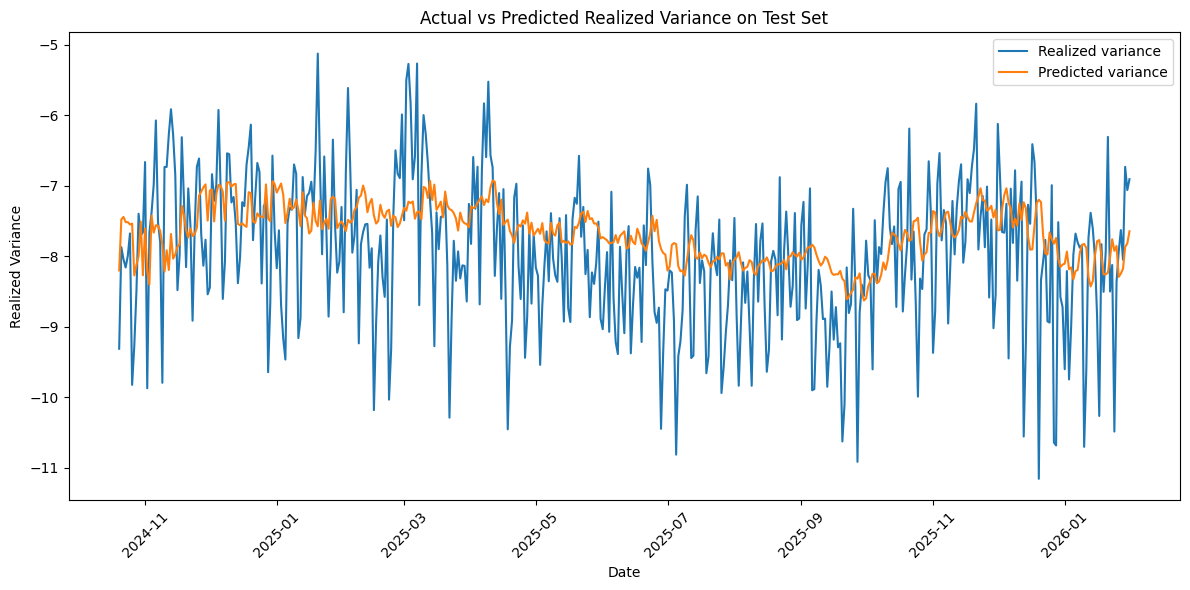

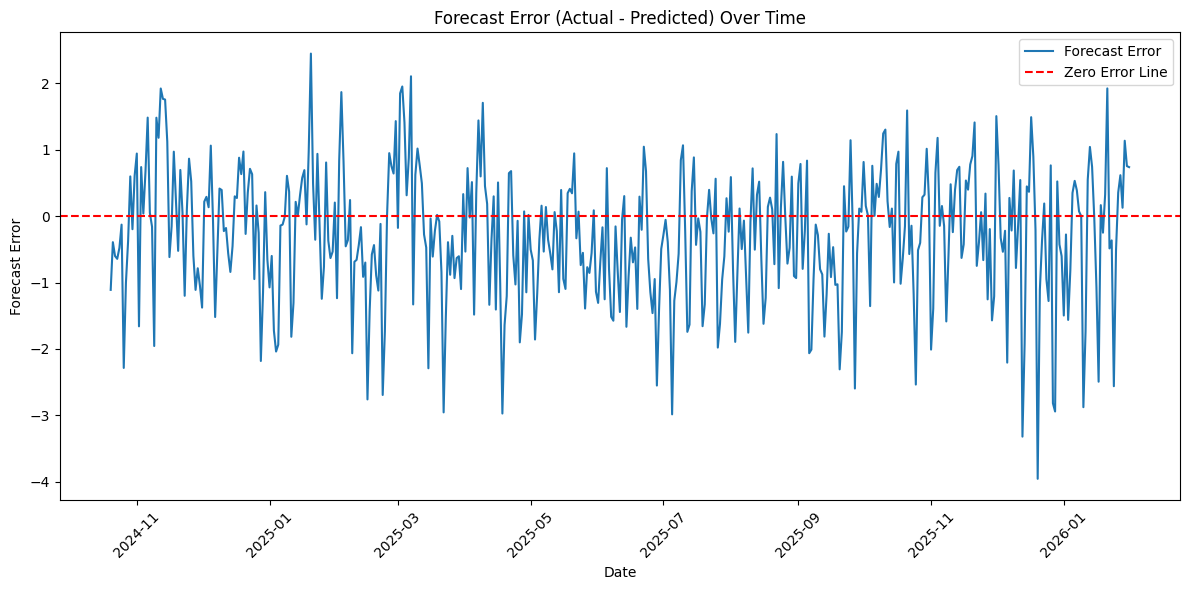

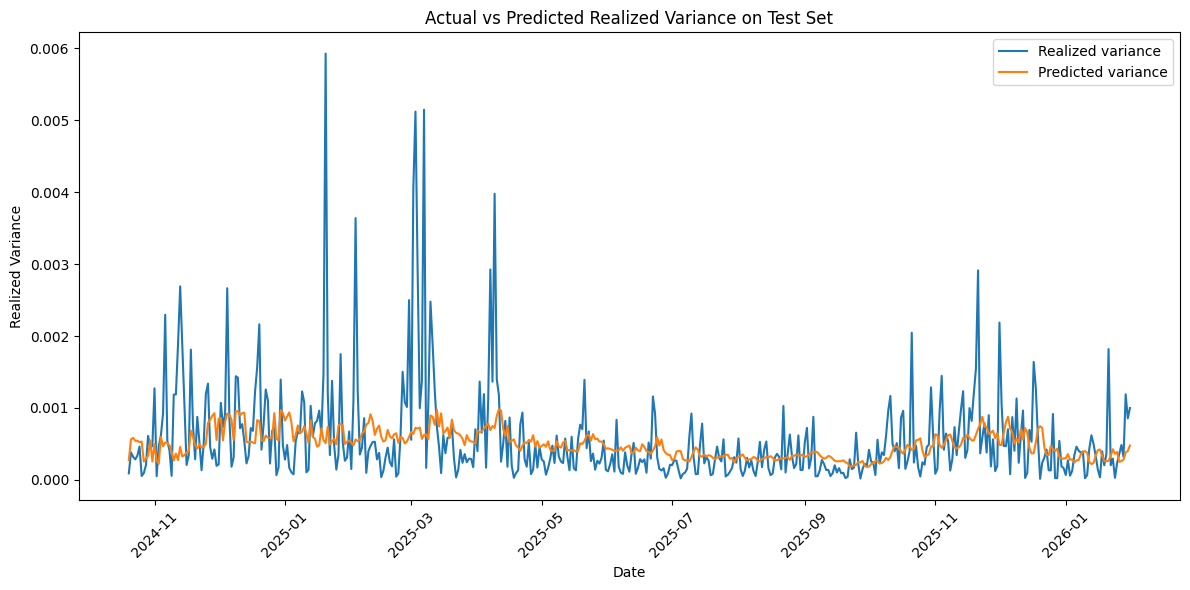

In [42]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_log_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["log_var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_log_var"] - test_svr["log_var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_log_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["log_var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
# save predictions
test_svr.to_csv("results/lstm-svr1.csv", index=False)




In [44]:
df['date'] = pd.to_datetime(df['date'])
test_svr['date'] = pd.to_datetime(test_svr['date'])

result_df = test_svr.merge(
    df[["date", "regime_id"]],
    on="date",
    how="left"
)

result_df = result_df.rename(columns={"regime_id": "actual_regime"})

result_df.head(20)

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr,error,actual_regime
0,2024-10-20,2024-10-19,-9.314845,0.0,1.000000e+00,4.467377e-11,-8.204093,-1.110752,0.0
1,2024-10-21,2024-10-20,-7.873473,1.0,1.469666e-01,8.530334e-01,-7.481550,-0.391923,0.0
2,2024-10-22,2024-10-21,-8.046507,1.0,4.403332e-10,1.000000e+00,-7.444665,-0.601842,0.0
3,2024-10-23,2024-10-22,-8.161787,1.0,5.299525e-06,9.999948e-01,-7.518562,-0.643225,0.0
4,2024-10-24,2024-10-23,-7.997675,1.0,1.405363e-07,9.999999e-01,-7.518750,-0.478924,0.0
5,2024-10-25,2024-10-24,-7.679053,1.0,6.312127e-10,1.000000e+00,-7.551547,-0.127506,1.0
6,2024-10-26,2024-10-25,-9.827359,1.0,6.426204e-06,9.999936e-01,-7.540000,-2.287359,0.0
7,2024-10-27,2024-10-26,-9.277379,0.0,1.000000e+00,1.465214e-12,-8.274092,-1.003287,0.0
8,2024-10-28,2024-10-27,-8.498660,0.0,9.999990e-01,9.331055e-07,-8.124487,-0.374173,0.0
9,2024-10-29,2024-10-28,-7.399876,0.0,6.921220e-01,3.078780e-01,-7.999084,0.599208,1.0


In [45]:
# classification report of predicted regime vs actual regime on test set
from sklearn.metrics import classification_report
# drop rows with NaN in pred_regime or actual_regime
result_df_clf = result_df.dropna(subset=["pred_regime", "actual_regime"])
print(classification_report(result_df_clf["actual_regime"], result_df_clf["pred_regime"]))


              precision    recall  f1-score   support

         0.0       0.54      0.58      0.56       214
         1.0       0.62      0.58      0.60       255

    accuracy                           0.58       469
   macro avg       0.58      0.58      0.58       469
weighted avg       0.59      0.58      0.58       469



# Feature importance

In [55]:
from sklearn.metrics import f1_score


def macro_f1_metric(y_true, y_pred):
    y_pred = np.array(y_pred)

    # multiclass / softmax case
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred_class = np.argmax(y_pred, axis=1)
    # binary sigmoid case
    else:
        y_pred_class = (y_pred.ravel() >= 0.5).astype(int)

    return f1_score(y_true, y_pred_class, average="macro")

In [56]:
def permutation_importance_lstm(model, X, y, metric_fn):
    baseline_pred = model.predict(X, verbose=0)
    baseline_score = metric_fn(y, baseline_pred)

    importances = []

    for j in range(X.shape[2]):  # loop over features
        X_permuted = X.copy()

        # permute feature j across samples
        perm_idx = np.random.permutation(X.shape[0])
        X_permuted[:, :, j] = X_permuted[perm_idx, :, j]

        perm_pred = model.predict(X_permuted, verbose=0)
        perm_score = metric_fn(y, perm_pred)

        importance = baseline_score - perm_score
        importances.append(importance)

    return np.array(importances)

In [57]:
X_test_lstm, y_test_regime, test_dates = create_rolling_scaled_sequences_range(
    df=test_df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=365,
    start_idx=0,
    end_idx=len(test_df),
    date_col="date"
)

importances = permutation_importance_lstm(
    model=final_lstm_model,
    X=X_test_lstm,
    y=y_test_regime,
    metric_fn=macro_f1_metric
)

In [61]:
importance_df = pd.DataFrame({
    "feature": lstm_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

                                       feature  importance
6                                   log_volume    0.073596
0                                   log_return    0.033583
22                           nasdaq_volume_chg    0.031908
20                              spx_volume_chg    0.023735
15                            usdeur_close_ret    0.020048
5   blockchain_diff_log_transaction_volume_usd    0.016750
19                              dji_volume_chg    0.016750
12                               rut_close_ret    0.016750
25                              difficulty_chg    0.015575
2           blockchain_diff_log_n_transactions    0.011776
23                               vix_close_chg    0.011776
8                             silver_close_ret    0.011776
7                               gold_close_ret    0.011734
14                            usdcny_close_ret    0.008367
9                              brent_close_ret    0.003516
10                               dji_close_ret    0.0000

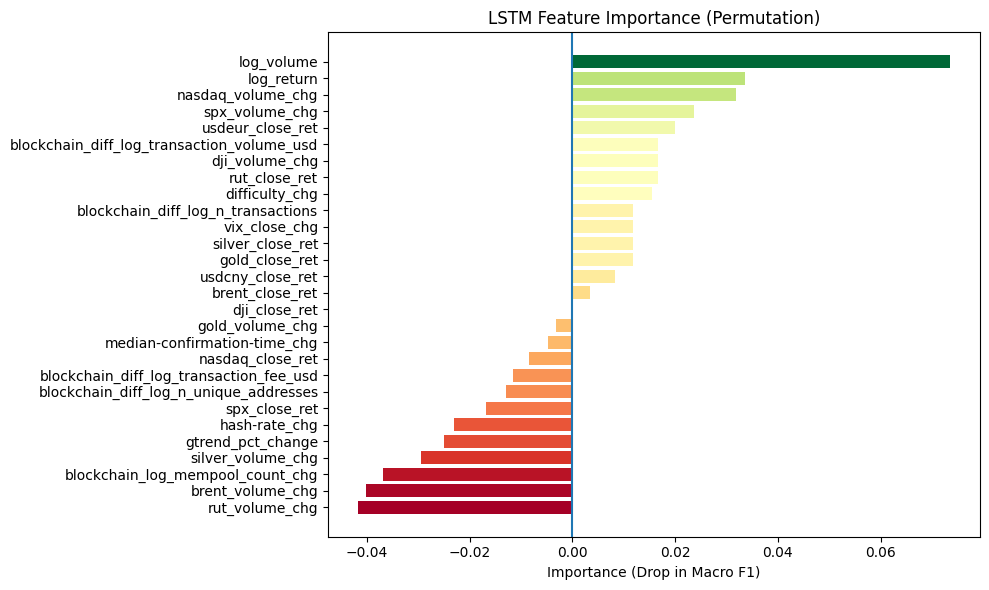

In [69]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 28
plot_df = importance_df.head(top_n).iloc[::-1]

values = plot_df["importance"].values

# normalize values to [-1, 1]
norm = plt.Normalize(vmin=values.min(), vmax=values.max())


cmap = plt.cm.RdYlGn

colors = cmap(norm(values))

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"], color=colors)

plt.axvline(0)

plt.title("LSTM Feature Importance (Permutation)")
plt.xlabel("Importance (Drop in Macro F1)")

plt.tight_layout()
plt.show()

# Shapely values

In [77]:
import shap

In [78]:
import shap
# 1. average features
X_avg = X_test_lstm.mean(axis=1)

# 2. wrapper
def model_wrapper(X_input):
    X_seq = np.repeat(X_input[:, None, :], best_lb, axis=1)
    return final_lstm_model.predict(X_seq, verbose=0)

# 3. explainer
explainer = shap.KernelExplainer(model_wrapper, X_avg[:100])

# 4. shap values
shap_values = explainer.shap_values(X_avg[:100])


  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_1284/3068456376.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


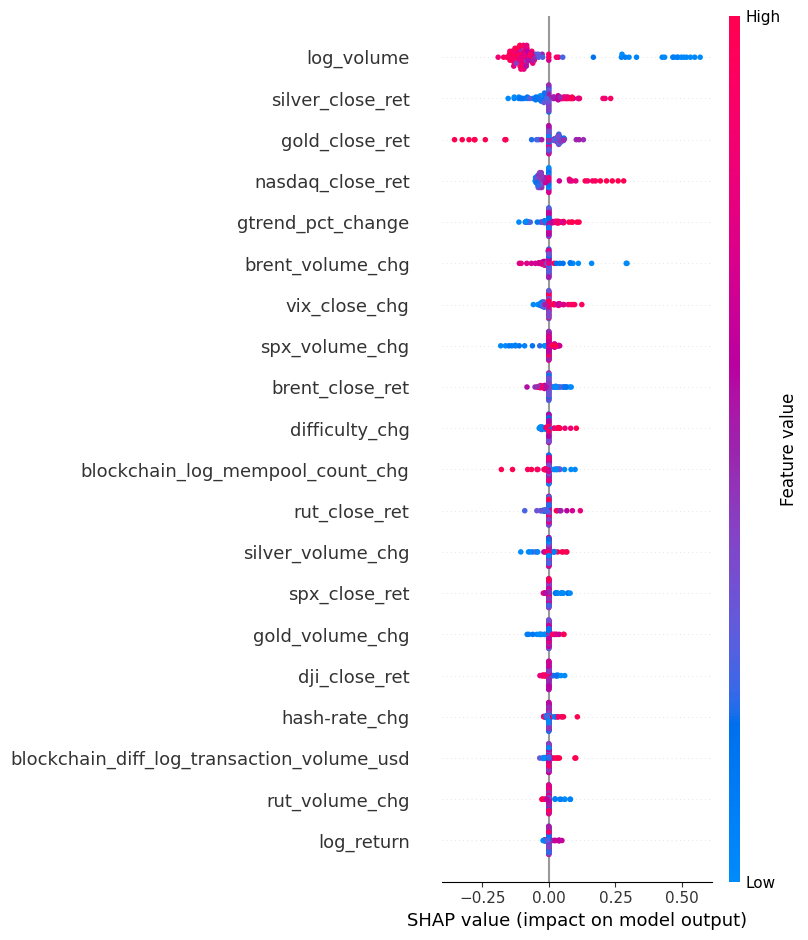

In [79]:
shap_class1 = shap_values[:, :, 1]

shap.summary_plot(
    shap_class1,
    X_avg[:100],
    feature_names=lstm_features
)

In [80]:
import shap


# =====================================================
# 1. Flatten LSTM input
# =====================================================
n_samples, n_timesteps, n_features = X_test_lstm.shape
X_test_flat = X_test_lstm.reshape(n_samples, n_timesteps * n_features)

# feature names with lag
feature_names = []
for lag in range(n_timesteps):
    for feat in lstm_features:
        feature_names.append(f"{feat}_t-{n_timesteps-1-lag}")

# =====================================================
# 2. Wrapper
# =====================================================
def model_wrapper(X_input):
    X_input = np.array(X_input)
    X_seq = X_input.reshape(-1, n_timesteps, n_features)
    preds = final_lstm_model.predict(X_seq, verbose=0)
    return preds  # shape: (n_samples, 2)

# =====================================================
# 3. Background + explain set (keep small)
# =====================================================
background = X_test_flat[:30]
X_explain = X_test_flat[:50]

# =====================================================
# 4. SHAP
# =====================================================
explainer = shap.KernelExplainer(model_wrapper, background)
shap_values = explainer.shap_values(X_explain)

print("SHAP computed.")

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP computed.


/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_1284/3162680757.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


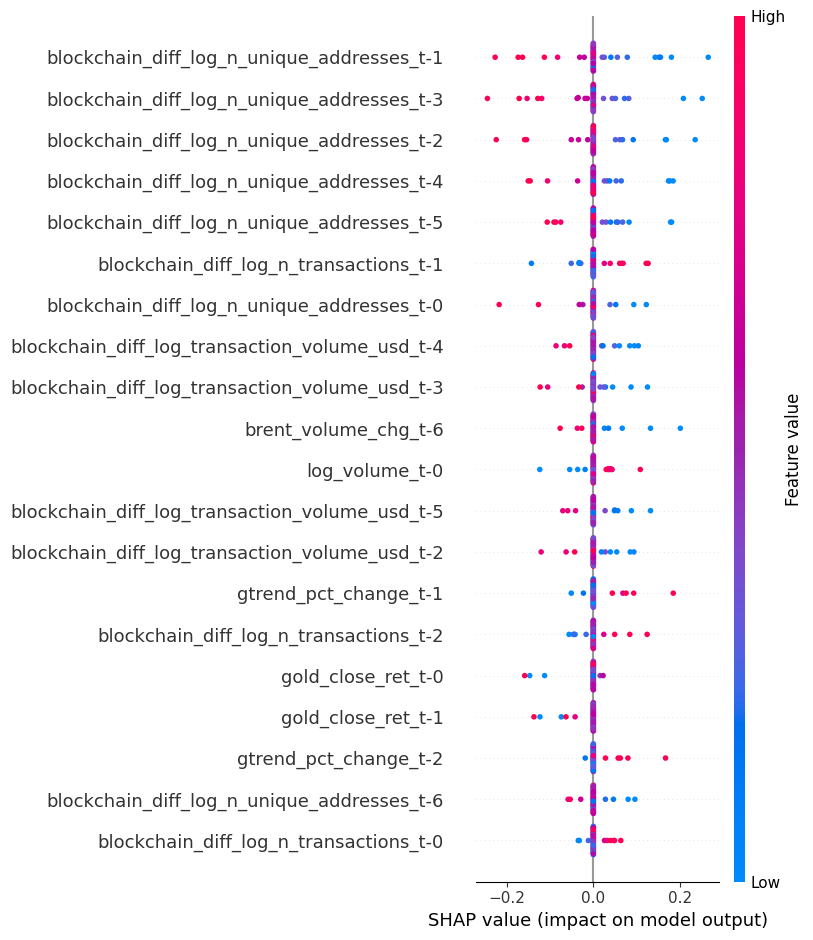

In [81]:
# handle different SHAP formats
if isinstance(shap_values, list):
    shap_high = shap_values[1]
else:
    shap_high = shap_values[:, :, 1]

shap.summary_plot(
    shap_high,
    X_explain,
    feature_names=feature_names
)

X_test_lstm shape: (104, 60, 28)
X_test_flat shape: (104, 1680)
background shape: (30, 1680)
X_explain shape: (100, 1680)


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP computed.
3D SHAP output detected: (100, 1680, 2)
Selected SHAP array shape: (100, 1680)
sv_3d shape: (100, 60, 28)
X_explain_3d shape: (100, 60, 28)
sv_lag shape: (100, 1680)
X_lag shape: (100, 1680)


/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_1284/799558395.py:112: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


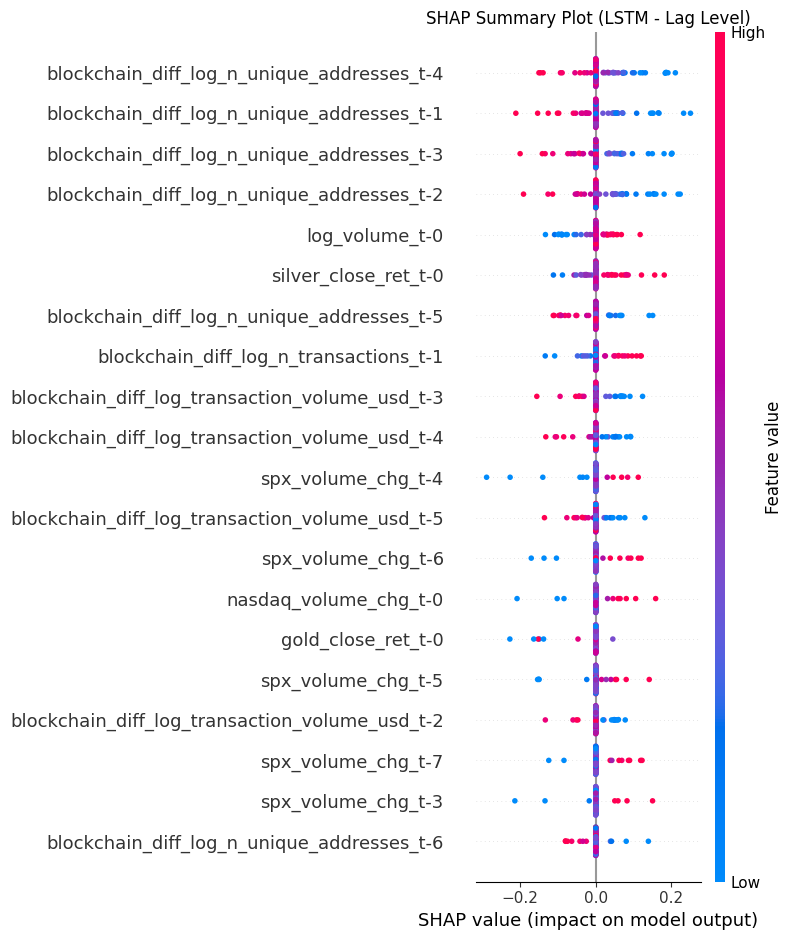

sv_feature shape: (100, 28)
X_feature shape: (100, 28)


/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_1284/799558395.py:139: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


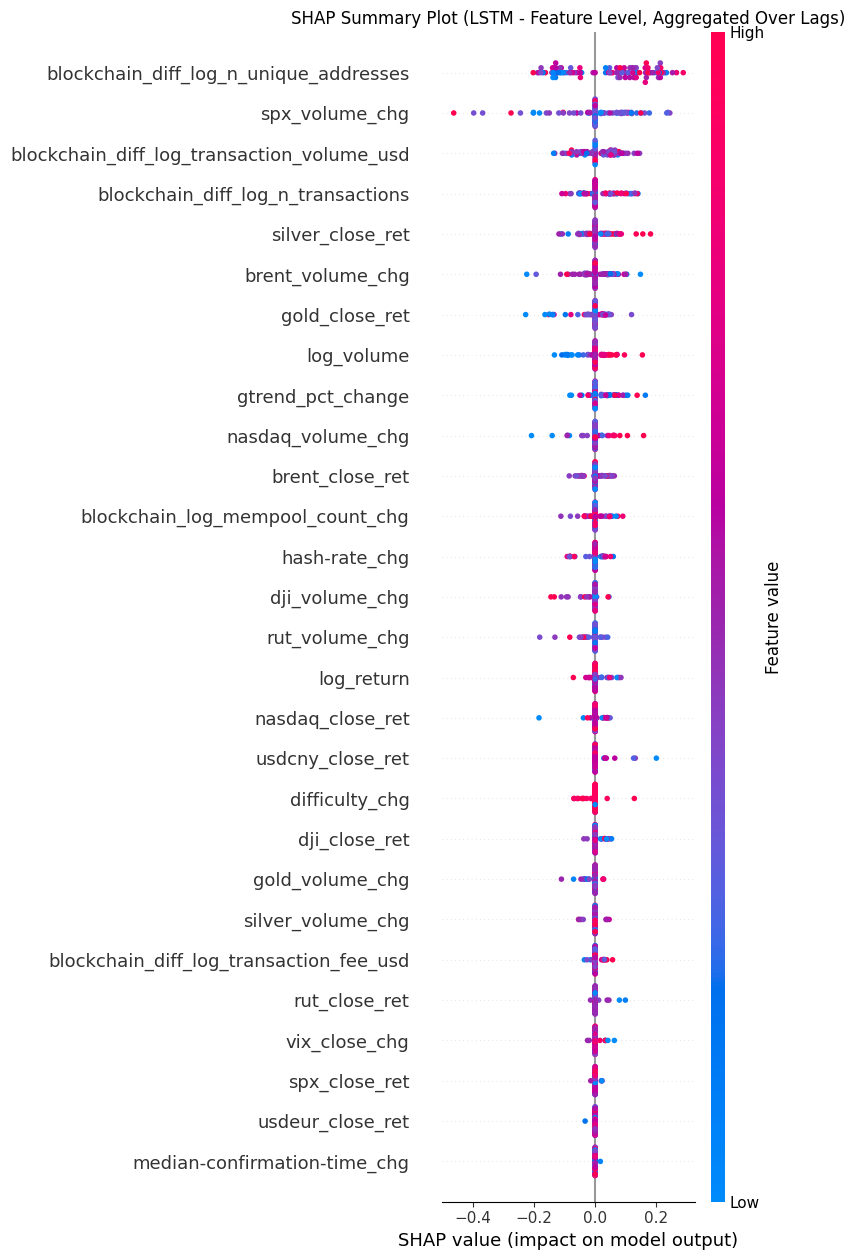


LSTM Feature Importance (aggregated over lags):
                                       feature  mean_abs_shap
4       blockchain_diff_log_n_unique_addresses       0.156096
20                              spx_volume_chg       0.069333
5   blockchain_diff_log_transaction_volume_usd       0.056334
2           blockchain_diff_log_n_transactions       0.033656
8                             silver_close_ret       0.027846
18                            brent_volume_chg       0.027142
7                               gold_close_ret       0.022400
6                                   log_volume       0.020442
1                            gtrend_pct_change       0.020438
22                           nasdaq_volume_chg       0.014079
9                              brent_close_ret       0.013608
19                              dji_volume_chg       0.011896
27            blockchain_log_mempool_count_chg       0.010961
24                               hash-rate_chg       0.010466
21                   

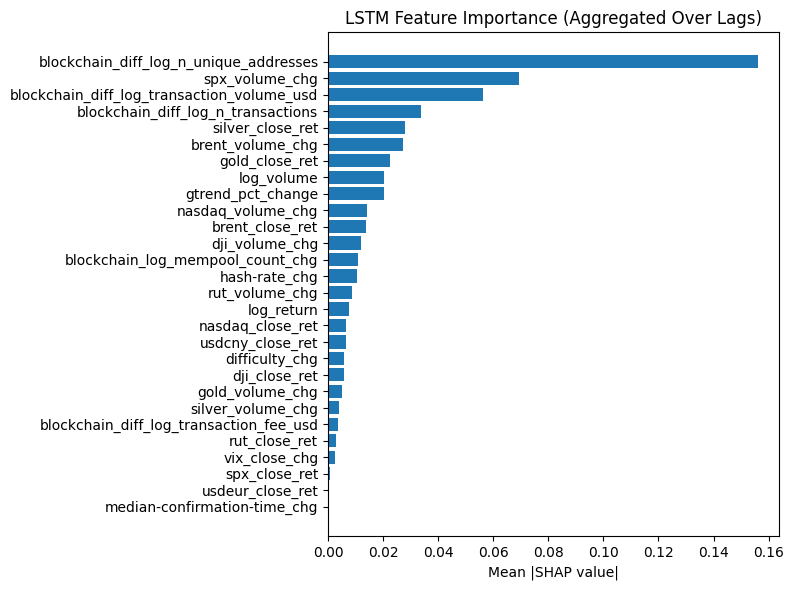


Top 15 LSTM Lag Importance:
     lag  mean_abs_shap
59   t-0       0.097512
58   t-1       0.092892
57   t-2       0.073825
56   t-3       0.073166
55   t-4       0.069338
54   t-5       0.046228
53   t-6       0.031962
52   t-7       0.017937
51   t-8       0.013057
49  t-10       0.007605
50   t-9       0.006090
46  t-13       0.004387
47  t-12       0.003106
44  t-15       0.002695
48  t-11       0.002675


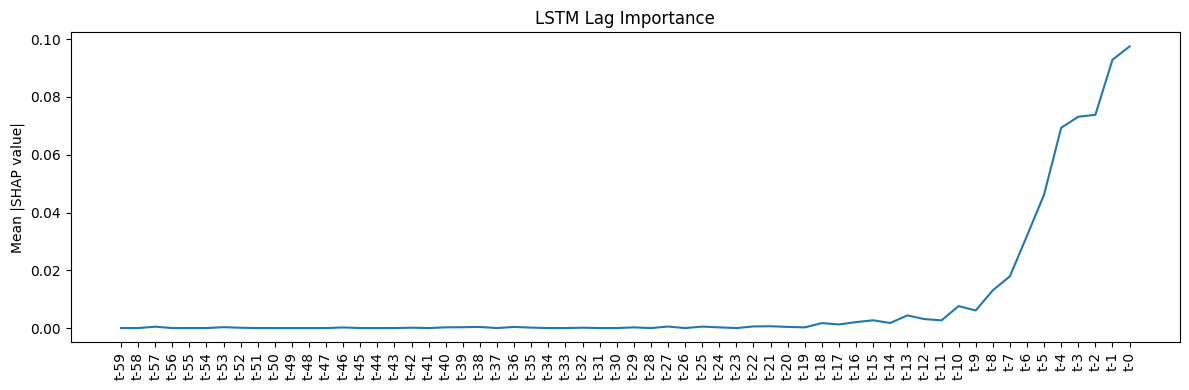


Feature x Lag importance matrix shape: (60, 28)


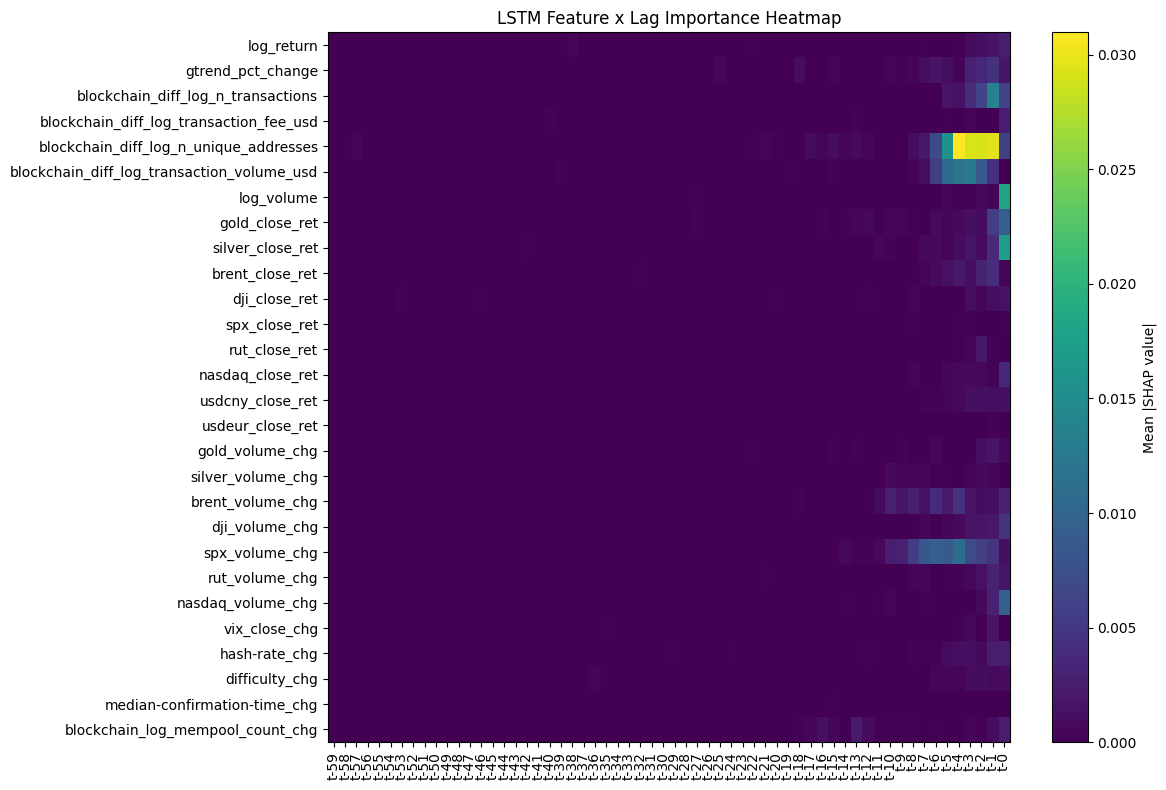

In [90]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


# inputs: 
# - final_lstm_model
# - X_test_lstm              shape: (n_test, n_timesteps, n_features)
# - lstm_features            
# =====================================================

# -----------------------------
# 0. Basic dimensions
# -----------------------------
n_test, n_timesteps, n_features = X_test_lstm.shape
print("X_test_lstm shape:", X_test_lstm.shape)

# -----------------------------
# 1. Flatten LSTM input
# -----------------------------
X_test_flat = X_test_lstm.reshape(n_test, n_timesteps * n_features)
print("X_test_flat shape:", X_test_flat.shape)

# lagged feature names for lag-level SHAP plot
lag_feature_names = []
for lag in range(n_timesteps):
    for feat in lstm_features:
        lag_feature_names.append(f"{feat}_t-{n_timesteps - 1 - lag}")

# -----------------------------
# 2. Wrapper for KernelExplainer
# -----------------------------
def model_wrapper(X_input):
    X_input = np.array(X_input)
    X_seq = X_input.reshape(-1, n_timesteps, n_features)
    preds = final_lstm_model.predict(X_seq, verbose=0)
    return preds   # shape: (n_samples, n_classes)

# -----------------------------
# 3. Select background and explain set
# Kernel SHAP is slow, so keep this small
# -----------------------------
np.random.seed(42)

background_size = min(30, n_test)
explain_size = min(100, n_test)

background_idx = np.random.choice(n_test, background_size, replace=False)
remaining_idx = np.setdiff1d(np.arange(n_test), background_idx)

if len(remaining_idx) >= explain_size:
    explain_idx = np.random.choice(remaining_idx, explain_size, replace=False)
else:
    explain_idx = np.random.choice(n_test, explain_size, replace=False)

background = X_test_flat[background_idx]
X_explain = X_test_flat[explain_idx]

print("background shape:", background.shape)
print("X_explain shape:", X_explain.shape)

# -----------------------------
# 4. Compute SHAP
# -----------------------------
explainer = shap.KernelExplainer(model_wrapper, background)
shap_values = explainer.shap_values(X_explain)

print("SHAP computed.")

# -----------------------------
# 5. Pick class to explain (high regime in this case)
# -----------------------------
if isinstance(shap_values, list):
    print("shap_values is a list with length:", len(shap_values))
    sv = shap_values[1]
else:
    sv = shap_values

# Some SHAP versions may return 3D output: (samples, flat_features, classes)
if sv.ndim == 3:
    print("3D SHAP output detected:", sv.shape)
    sv = sv[:, :, 1]

print("Selected SHAP array shape:", sv.shape)

# -----------------------------
# 6. Reshape SHAP back to 3D
# shape: (n_explain, n_timesteps, n_features)
# -----------------------------
n_explain = sv.shape[0]
sv_3d = sv.reshape(n_explain, n_timesteps, n_features)

# reshape explained inputs too
X_explain_3d = X_explain.reshape(n_explain, n_timesteps, n_features)

print("sv_3d shape:", sv_3d.shape)
print("X_explain_3d shape:", X_explain_3d.shape)

# =====================================================
# PART A: LAG-LEVEL SHAP (shows feature x lag importance)
# =====================================================

# flatten SHAP back to 2D for lag-level plot
sv_lag = sv_3d.reshape(n_explain, n_timesteps * n_features)
X_lag = X_explain_3d.reshape(n_explain, n_timesteps * n_features)

print("sv_lag shape:", sv_lag.shape)
print("X_lag shape:", X_lag.shape)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_lag,
    X_lag,
    feature_names=lag_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot (LSTM - Lag Level)")
plt.tight_layout()
plt.show()

# =====================================================
# PART B: FEATURE-LEVEL SHAP (aggregated over lags)
# one row per original feature
# =====================================================


# signed (sum) aggregation over lags
sv_feature = sv_3d.sum(axis=1)     # shape: (n_explain, n_features)

# use last timestep feature values for coloring
X_feature = X_explain_3d[:, -1, :] # shape: (n_explain, n_features)

print("sv_feature shape:", sv_feature.shape)
print("X_feature shape:", X_feature.shape)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_feature,
    X_feature,
    feature_names=lstm_features,
    max_display=len(lstm_features),
    show=False
)
plt.title("SHAP Summary Plot (LSTM - Feature Level, Aggregated Over Lags)")
plt.tight_layout()
plt.show()

# =====================================================
# PART C: mean absolute SHAP aggregated over lags
# =====================================================


feature_importance = np.abs(sv_3d).sum(axis=1).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": lstm_features,
    "mean_abs_shap": feature_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nLSTM Feature Importance (aggregated over lags):")
print(feature_importance_df)

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["mean_abs_shap"][::-1]
)
plt.xlabel("Mean |SHAP value|")
plt.title("LSTM Feature Importance (Aggregated Over Lags)")
plt.tight_layout()
plt.show()

# =====================================================
# PART D: LAG IMPORTANCE TABLE + BAR CHART
# determine which timestamp (60 lags) matter the most
# =====================================================

lag_importance = np.abs(sv_3d).mean(axis=0).sum(axis=1)

lag_labels = [f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)]

lag_importance_df = pd.DataFrame({
    "lag": lag_labels,
    "mean_abs_shap": lag_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 15 LSTM Lag Importance:")
print(lag_importance_df.head(15))

# plot in original time order
lag_importance_plot_df = pd.DataFrame({
    "lag": [f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)],
    "mean_abs_shap": np.abs(sv_3d).mean(axis=0).sum(axis=1)
})

plt.figure(figsize=(12, 4))
plt.plot(lag_importance_plot_df["lag"], lag_importance_plot_df["mean_abs_shap"])
plt.xticks(rotation=90)
plt.ylabel("Mean |SHAP value|")
plt.title("LSTM Lag Importance")
plt.tight_layout()
plt.show()

# =====================================================
# PART E: FEATURE x LAG HEATMAP
# determine feature matters at which lag
# =====================================================

feature_lag_importance = np.abs(sv_3d).mean(axis=0)   # shape: (timesteps, features)

feature_lag_df = pd.DataFrame(
    feature_lag_importance,
    columns=lstm_features,
    index=[f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)]
)

print("\nFeature x Lag importance matrix shape:", feature_lag_df.shape)

plt.figure(figsize=(12, 8))
plt.imshow(feature_lag_df.T, aspect='auto')
plt.yticks(range(len(lstm_features)), lstm_features)
plt.xticks(range(n_timesteps), feature_lag_df.index, rotation=90)
plt.colorbar(label="Mean |SHAP value|")
plt.title("LSTM Feature x Lag Importance Heatmap")
plt.tight_layout()
plt.show()


In [91]:
# save outputs

feature_importance_df.to_csv("model_final/lstm_feature_importance_shap.csv", index=False)
lag_importance_df.to_csv("model_final/lstm_lag_importance_shap.csv", index=False)
feature_lag_df.to_csv("model_final/lstm_feature_lag_importance_shap.csv")

print("\nSaved files:")
print("- lstm_feature_importance_shap.csv")
print("- lstm_lag_importance_shap.csv")
print("- lstm_feature_lag_importance_shap.csv")


Saved files:
- lstm_feature_importance_shap.csv
- lstm_lag_importance_shap.csv
- lstm_feature_lag_importance_shap.csv
